In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ceres = xr.open_dataset(r"D://Niharika Work//Climate_Project//CERES_EBAF-TOA_Edition4.1-20260303_075023//CERES_EBAF-TOA_Edition4.1_200003-202203.nc")

| CERES Variable     | Meaning            | CMIP6 Equivalent     |
| ------------------ | ------------------ | -------------------- |
| `toa_sw_all_mon`   | outgoing shortwave | `rsut`               |
| `toa_lw_all_mon`   | outgoing longwave  | `rlut`               |
| `toa_net_all_mon`  | net TOA radiation  | `rsdt - rsut - rlut` |
| `toa_sw_clr_c_mon` | clear-sky SW       | `rsutcs`             |
| `toa_lw_clr_c_mon` | clear-sky LW       | `rlutcs`             |

In [3]:
print(ceres)

<xarray.Dataset> Size: 792MB
Dimensions:                        (lon: 360, lat: 180, ctime: 12, sc: 2,
                                    time: 265)
Coordinates:
  * lon                            (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                            (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * ctime                          (ctime) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * time                           (time) datetime64[ns] 2kB 2000-03-15 ... 2...
Dimensions without coordinates: sc
Data variables: (12/67)
    climatology_bounds             (ctime, sc) int32 96B ...
    toa_sw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_lw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_net_all_mon                (time, lat, lon) float32 69MB ...
    toa_sw_clr_c_mon               (time, lat, lon) float32 69MB ...
    toa_lw_clr_c_mon               (time, lat, lon) float32 69MB ...
    ...                             ...
    gtoa_n

In [4]:
list(ceres.data_vars)

['climatology_bounds',
 'toa_sw_all_mon',
 'toa_lw_all_mon',
 'toa_net_all_mon',
 'toa_sw_clr_c_mon',
 'toa_lw_clr_c_mon',
 'toa_net_clr_c_mon',
 'solar_mon',
 'cldarea_total_daynight_mon',
 'cldpress_total_daynight_mon',
 'cldtemp_total_daynight_mon',
 'cldtau_total_day_mon',
 'toa_sw_all_clim',
 'toa_lw_all_clim',
 'toa_net_all_clim',
 'toa_sw_clr_c_clim',
 'toa_lw_clr_c_clim',
 'toa_net_clr_c_clim',
 'solar_clim',
 'cldarea_total_daynight_clim',
 'cldpress_total_daynight_clim',
 'cldtemp_total_daynight_clim',
 'cldtau_total_day_clim',
 'ztoa_sw_all_mon',
 'ztoa_lw_all_mon',
 'ztoa_net_all_mon',
 'ztoa_sw_clr_c_mon',
 'ztoa_lw_clr_c_mon',
 'ztoa_net_clr_c_mon',
 'zsolar_mon',
 'zcldarea_total_daynight_mon',
 'zcldpress_total_daynight_mon',
 'zcldtemp_total_daynight_mon',
 'zcldtau_total_day_mon',
 'ztoa_sw_all_clim',
 'ztoa_lw_all_clim',
 'ztoa_net_all_clim',
 'ztoa_sw_clr_c_clim',
 'ztoa_lw_clr_c_clim',
 'ztoa_net_clr_c_clim',
 'zsolar_clim',
 'zcldarea_total_daynight_clim',
 'zcldp

In [5]:
# R = ceres['toa_net_all_mon']

# SW = ceres['toa_sw_all_mon']
# LW = ceres['toa_lw_all_mon']

# SW_clear = ceres['toa_sw_clr_c_mon']
# LW_clear = ceres['toa_lw_clr_c_mon']

# Compute Cloud Radiative Effect (CRE) from CERES

To compute the Cloud Radiative Effect (CRE) exactly like CMIP6 using CERES data, use the following definitions based on all-sky and clear-sky fluxes.

## Formulas

### Shortwave (SW) CRE
$$CRE_{SW} = SW_{clear} - SW_{all}$$

### Longwave (LW) CRE
$$CRE_{LW} = LW_{clear} - LW_{all}$$

## Variable Definitions


| Variable | Description | CERES Variable Name (Example) |
| :--- | :--- | :--- |
| **$SW_{all}$** | TOA Net Shortwave Flux - All-Sky | `toa_sw_all_mon` |
| **$SW_{clear}$**| TOA Net Shortwave Flux - Clear-Sky | `toa_sw_clr_mon` |
| **$LW_{all}$** | TOA Longwave Flux - All-Sky | `toa_lw_all_mon` |
| **$LW_{clear}$**| TOA Longwave Flux - Clear-Sky | `toa_lw_clr_mon` |

*Note: For consistent CMIP6-style calculation, ensure you are using Net Fluxes (Downwelling - Upwelling) for SW, and Upwelling Fluxes for LW.*


### Compute Global Radiation Time Series

In [6]:
# sw_cre = SW_clear - SW
# lw_cre = LW_clear - LW

# net_cre = sw_cre + lw_cre

In [7]:
# import numpy as np

# weights = np.cos(np.deg2rad(ceres.lat))

# R_global = R.weighted(weights).mean(("lat","lon"))

In [8]:
# R_global = ceres['gtoa_net_all_mon']

In [9]:
# ceres = ceres.sel(time=slice("2001","2014"))

In [10]:
import xarray as xr

era5 = xr.open_dataset("D://Niharika Work//Climate_Project//ERA5_temperature/ceb0d88e509872628f04434b2a0c5d5d.nc")

print(era5)

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 300, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 2kB 2000-01-01 ... 2024-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 5kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T15:13 GRIB to CDM+CF via cfgrib-0.9.1...


In [11]:
T = era5.rename({"valid_time":"time"})

In [12]:
# T = T.sel(time=slice("2001","2014"))
# T = era5["t2m"].sel(valid_time=slice("2001","2014"))
T = T["t2m"].sel(time=slice("2001","2014"))

### Compute Global Mean Temperature

In [13]:
import numpy as np

weights = np.cos(np.deg2rad(T.latitude))

T_global = T.weighted(weights).mean(("latitude","longitude"))

### Compute CERES Radiation

In [14]:
R = ceres['toa_net_all_mon']

weights = np.cos(np.deg2rad(ceres.lat))

R_global = R.weighted(weights).mean(("lat","lon"))

In [19]:
# Convert both datasets to pandas DataFrame

T_df = T_global.to_dataframe(name="T")
R_df = R_global.to_dataframe(name="R")

In [22]:
# Merge using year and month

merged = T_df.merge(R_df, on=["year","month"])

In [23]:
print(len(merged))

168


In [ ]:
# T_aligned, R_aligned = xr.align(T_global, R_global, join="inner")

In [ ]:
# # Extract year and month

# T_df["year"] = T_df.index.year
# T_df["month"] = T_df.index.month

# R_df["year"] = R_df.index.year
# R_df["month"] = R_df.index.month

### Compute Anomalies

In [24]:
# # T_anom = T_global - T_global.mean("time")
# # R_anom = R_global - R_global.mean("time")

# T_anom = T_aligned - T_aligned.mean()
# R_anom = R_aligned - R_aligned.mean()

T_anom = merged["T"] - merged["T"].mean()
R_anom = merged["R"] - merged["R"].mean()

In [25]:
print(len(T_anom))
print(len(R_anom))

168
168


### Compute Feedback λ

In [28]:
# lambda_feedback = np.polyfit(T_anom, R_anom, 1)[0]

lambda_feedback = np.polyfit(
    T_anom.values,
    R_anom.values,
    1
)[0]

print("Observed feedback λ =", lambda_feedback, "W m^-2 K^-1")

Observed feedback λ = -4.3177188805615705 W m^-2 K^-1


### Gregory Plot (CERES + ERA5)

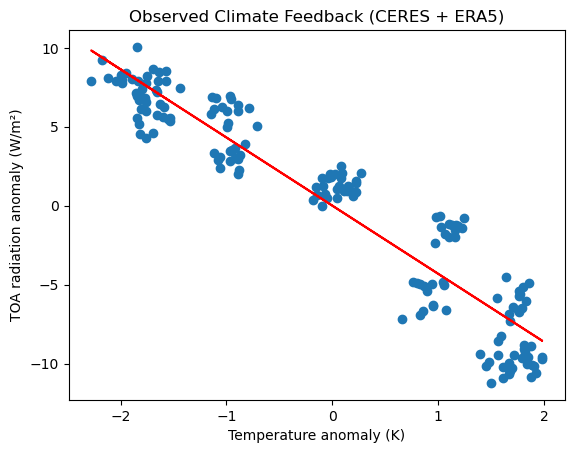

In [29]:
import matplotlib.pyplot as plt

plt.scatter(T_anom, R_anom)

fit = np.polyfit(T_anom, R_anom, 1)
plt.plot(T_anom, fit[0]*T_anom + fit[1], color="red")

plt.xlabel("Temperature anomaly (K)")
plt.ylabel("TOA radiation anomaly (W/m²)")
plt.title("Observed Climate Feedback (CERES + ERA5)")

plt.show()

In [30]:
print(T_global.mean().values)

287.54126077625926


In [31]:
print(R_global.mean().values)

1.0543739


In [32]:
print(T_anom.min(), T_anom.max())
print(R_anom.min(), R_anom.max())

-2.277343493128569 1.9807672960061495
-11.228049 10.055507


In [34]:
print("T anomaly range:", float(T_anom.min()), float(T_anom.max()))
print("R anomaly range:", float(R_anom.min()), float(R_anom.max()))

T anomaly range: -2.277343493128569 1.9807672960061495
R anomaly range: -11.228049278259277 10.055506706237793


Text(0.5, 1.0, 'CERES + ERA5 Gregory Regression')

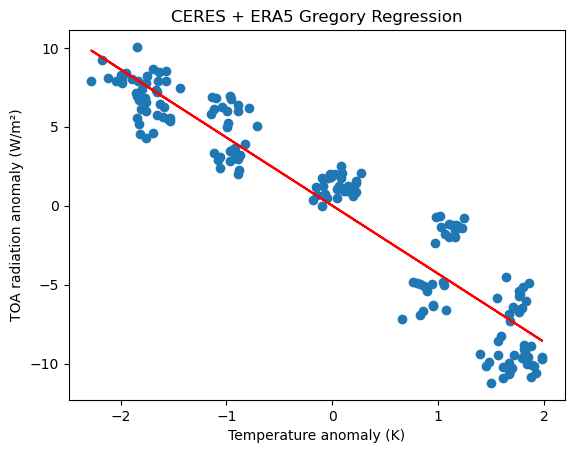

In [33]:
plt.scatter(T_anom, R_anom)

fit = np.polyfit(T_anom, R_anom, 1)
plt.plot(T_anom, fit[0]*T_anom + fit[1], color="red")

plt.xlabel("Temperature anomaly (K)")
plt.ylabel("TOA radiation anomaly (W/m²)")
plt.title("CERES + ERA5 Gregory Regression")

In [35]:
R_global = ceres["gtoa_net_all_mon"]

In [36]:
print(R_anom.min(), R_anom.max())

-11.228049 10.055507


In [37]:
lambda_feedback = np.polyfit(
    T_anom.values,
    R_anom.values,
    1
)[0]

print("Observed feedback λ =", lambda_feedback, "W m^-2 K^-1")

Observed feedback λ = -4.3177188805615705 W m^-2 K^-1


In [48]:
T_df = T_global.to_dataframe(name="T")
R_df = R_global.to_dataframe(name="R")

In [49]:
T_df["year"] = T_df.index.year
T_df["month"] = T_df.index.month

R_df["year"] = R_df.index.year
R_df["month"] = R_df.index.month

In [50]:
merged = T_df.merge(R_df, on=["year", "month"])

In [51]:
print(len(merged))

168


In [52]:
merged["T_anom"] = merged["T"] - merged.groupby("month")["T"].transform("mean")
merged["R_anom"] = merged["R"] - merged.groupby("month")["R"].transform("mean")

In [53]:
lambda_feedback = np.polyfit(
    merged["T_anom"],
    merged["R_anom"],
    1
)[0]

print("Observed feedback λ =", lambda_feedback, "W m^-2 K^-1")

Observed feedback λ = -1.0445356964655046 W m^-2 K^-1


In [ ]:
# # T_anom = T_global.groupby("time.month") - T_global.groupby("time.month").mean()
# # R_anom = R_global.groupby("time.month") - R_global.groupby("time.month").mean()

# T_anom = T_global.groupby("time.month") - T_global.groupby("time.month").mean()
# R_anom = R_global.groupby("time.month") - R_global.groupby("time.month").mean()

In [ ]:
# T_anom, R_anom = xr.align(T_anom, R_anom, join="inner")

In [ ]:
# T_vals = T_anom.values.flatten()
# R_vals = R_anom.values.flatten()

In [ ]:
# mask = np.isfinite(T_vals) & np.isfinite(R_vals)

# T_vals = T_vals[mask]
# R_vals = R_vals[mask]

In [ ]:
# print(R_anom.min(), R_anom.max())

<xarray.DataArray 'gtoa_net_all_mon' ()> Size: 4B
array(-1.5737467, dtype=float32) <xarray.DataArray 'gtoa_net_all_mon' ()> Size: 4B
array(1.8790035, dtype=float32)


In [ ]:
# print(len(T_vals), len(R_vals))

0 0


In [ ]:
# lambda_feedback = np.polyfit(T_vals, R_vals, 1)[0]

# print("Observed feedback λ =", lambda_feedback, "W m^-2 K^-1")

TypeError: expected non-empty vector for x